## Problem Statement

The US Department of Labor’s Office of Foreign Labor Certification (OFLC) receives hundreds of thousands of visa applications every year. Reviewing each application manually is time‑consuming and resource intensive. The aim of this project is to build and evaluate machine‑learning models that can predict whether a visa petition will be **certified** or **denied** based on attributes of the employer (e.g., number of employees, region of employment) and the applicant (e.g., continent of origin, education, job experience). Such a model can help prioritise applications for manual review and provide data‑driven insights into the factors most strongly associated with successful cases.

### Business Context

Business communities in the United States are facing high demand for human resources, but one of the constant challenges is identifying and attracting the right talent, which is perhaps the most important element in remaining competitive. Companies in the United States look for hard-working, talented, and qualified individuals both locally as well as abroad.

The Immigration and Nationality Act (INA) of the US permits foreign workers to come to the United States to work on either a temporary or permanent basis. The act also protects US workers against adverse impacts on their wages or working conditions by ensuring US employers' compliance with statutory requirements when they hire foreign workers to fill workforce shortages. The immigration programs are administered by the Office of Foreign Labor Certification (OFLC).

OFLC processes job certification applications for employers seeking to bring foreign workers into the United States and grants certifications in those cases where employers can demonstrate that there are not sufficient US workers available to perform the work at wages that meet or exceed the wage paid for the occupation in the area of intended employment.

### Objective

In FY 2016, the OFLC processed 775,979 employer applications for 1,699,957 positions for temporary and permanent labor certifications. This was a nine percent increase in the overall number of processed applications from the previous year. The process of reviewing every case is becoming a tedious task as the number of applicants is increasing every year.

The increasing number of applicants every year calls for a Machine Learning based solution that can help in shortlisting the candidates having higher chances of VISA approval. OFLC has hired the firm EasyVisa for data-driven solutions. You as a data scientist at EasyVisa have to analyze the data provided and, with the help of a classification model:

- Facilitate the process of visa approvals.
- Recommend a suitable profile for the applicants for whom the visa should be certified or denied based on the drivers that significantly influence the case status.

### Data Description

The data contains the different attributes of employee and the employer. The detailed data dictionary is given below.

- case_id: ID of each visa application
- continent: Information of continent the employee
- education_of_employee: Information of education of the employee
- has_job_experience: Does the employee has any job experience? Y= Yes; N = No
- requires_job_training: Does the employee require any job training? Y = Yes; N = No
- no_of_employees: Number of employees in the employer's company
- yr_of_estab: Year in which the employer's company was established
- region_of_employment: Information of foreign worker's intended region of employment in the US.
- prevailing_wage: Average wage paid to similarly employed workers in a specific occupation in the area of intended employment. The purpose of the prevailing wage is to ensure that the foreign worker is not underpaid compared to other workers offering the same or similar service in the same area of employment.
- unit_of_wage: Unit of prevailing wage. Values include Hourly, Weekly, Monthly, and Yearly.
- full_time_position: Is the position of work full-time? Y = Full Time Position; N = Part Time Position
- case_status: Flag indicating if the Visa was certified or denied

## Installing and Importing the necessary libraries

In [1]:
# Installing the libraries with the specified version.
!pip install numpy==1.25.2 pandas==1.5.3 scikit-learn==1.5.2 matplotlib==3.7.1 seaborn==0.13.1 xgboost==2.0.3 -q --user

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 62.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 30.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 34.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.8/294.8 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 297.1/297.1 MB 3.4 MB/s eta 0:00:00
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 1.5.3 which is incompatible.
xarray 2025.7.1 requires numpy>=1.26, but you have numpy 1.25.2 which is incompatible.
xarray 2025.7.1 requires pandas>=2.2, but you have pa

**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the below.*

In [2]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning tools
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.utils import resample

# Set plotting style
%matplotlib inline
sns.set(style='whitegrid', palette='Set2')

## Import Dataset

In [4]:
from google.colab import drive
drive.mount('/content/drive')  # follow the link → paste the code
# Example path
data_path = '/content/drive/MyDrive/EasyVisa/EasyVisa.csv'
visa_df = pd.read_csv(data_path)

# Make a copy for manipulation
visa_df = visa_df.copy()

Mounted at /content/drive

## Overview of the Dataset

#### View the first and last 5 rows of the dataset

In [5]:
# Display the first and last five rows of the dataset
print('First five rows:')
print(visa_df.head())
print('\nLast five rows:')
print(visa_df.tail())

First five rows:
  case_id continent education_of_employee has_job_experience  \
0  EZYV01      Asia           High School                  N   
1  EZYV02      Asia              Master's                  Y   
2  EZYV03      Asia            Bachelor's                  N   
3  EZYV04      Asia            Bachelor's                  N   
4  EZYV05    Africa              Master's                  Y   

  requires_job_training  no_of_employees  yr_of_estab region_of_employment  \
0                     N            14513         2007                 West   
1                     N             2412         2002            Northeast   
2                     Y            44444         2008                 West   
3                     N               98         1897                 West   
4                     N             1082         2005                South   

   prevailing_wage unit_of_wage full_time_position case_status  
0         592.2029         Hour                  Y      Denied  

#### Understand the shape of the dataset

In [6]:
# Understand the shape of the dataset
print(f'Number of rows: {visa_df.shape[0]}')
print(f'Number of columns: {visa_df.shape[1]}')

Number of rows: 25480
Number of columns: 12

#### Check the data types of the columns for the dataset

In [7]:
# Check the data types of the columns
print(visa_df.dtypes)

case_id                   object
continent                 object
education_of_employee     object
has_job_experience        object
requires_job_training     object
no_of_employees            int64
yr_of_estab                int64
region_of_employment      object
prevailing_wage          float64
unit_of_wage              object
full_time_position        object
case_status               object
dtype: object

## Exploratory Data Analysis (EDA)

#### Let's check the statistical summary of the data

In [8]:
# Statistical summary of numerical features
print(visa_df.describe())

       no_of_employees   yr_of_estab  prevailing_wage
count     25480.000000  25480.000000     25480.000000
mean       5667.043210   1979.409929     74455.814592
std       22877.928848     42.366929     52815.942327
min         -26.000000   1800.000000         2.136700
25%        1022.000000   1976.000000     34015.480000
50%        2109.000000   1997.000000     70308.210000
75%        3504.000000   2005.000000    107735.512500
max      602069.000000   2016.000000    319210.270000

#### Fixing the negative values in number of employees columns

In [9]:
# Fix negative values in number of employees
print('Negative values before fix:', (visa_df['no_of_employees'] < 0).sum())
visa_df['no_of_employees'] = visa_df['no_of_employees'].abs()
print('Negative values after fix:', (visa_df['no_of_employees'] < 0).sum())

Negative values before fix: 33
Negative values after fix: 0

#### Let's check the count of each unique category in each of the categorical variables

In [10]:
# Count of each unique category in categorical variables
categorical_cols = visa_df.select_dtypes(include='object').columns.tolist()
for col in categorical_cols:
    print(f"\nValue counts for {col}:")
    print(visa_df[col].value_counts())


Value counts for case_id:
case_id
EZYV25480    1
EZYV01       1
EZYV02       1
EZYV03       1
EZYV04       1
            ..
EZYV13       1
EZYV12       1
EZYV11       1
EZYV10       1
EZYV09       1
Name: count, Length: 25480, dtype: int64

Value counts for continent:
continent
Asia             16861
Europe            3732
North America     3292
South America      852
Africa             551
Oceania            192
Name: count, dtype: int64

Value counts for education_of_employee:
education_of_employee
Bachelor's     10234
Master's        9634
High School     3420
Doctorate       2192
Name: count, dtype: int64

Value counts for has_job_experience:
has_job_experience
Y    14802
N    10678
Name: count, dtype: int64

Value counts for requires_job_training:
requires_job_training
N    22525
Y     2955
Name: count, dtype: int64

Value counts for region_of_employment:
region_of_employment
Northeast    7195
South        7017
West         6586
Midwest      4307
Island        375
Name: count, dty

### Univariate Analysis

In [11]:
def histogram_boxplot(data, feature, figsize=(15, 10), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (15,10))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [12]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

#### Observations on education of employee

The bar plot shows that most applicants hold a **Bachelor's** degree (~40% of the dataset) or a **Master's** degree (~38%). Fewer applicants have completed **High School** (~13%) or possess a **Doctorate** (~9%). This suggests the applicant pool is relatively well‑educated, with post‑graduate degrees being fairly common.

/tmp/ipython-input-2559097902.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(

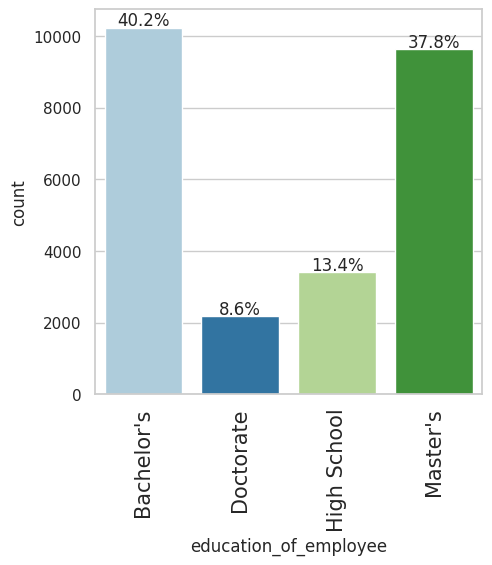

In [13]:
# Plot distribution of education levels
labeled_barplot(visa_df, 'education_of_employee', perc=True)

#### Observations on region of employment

The majority of applications are for positions in the **Northeast** and **South** regions of the United States, followed by the **West** and **Midwest**. Very few cases (~1%) target jobs on the U.S. island territories. The distribution suggests that demand is concentrated in the more populous economic regions.

/tmp/ipython-input-2559097902.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(

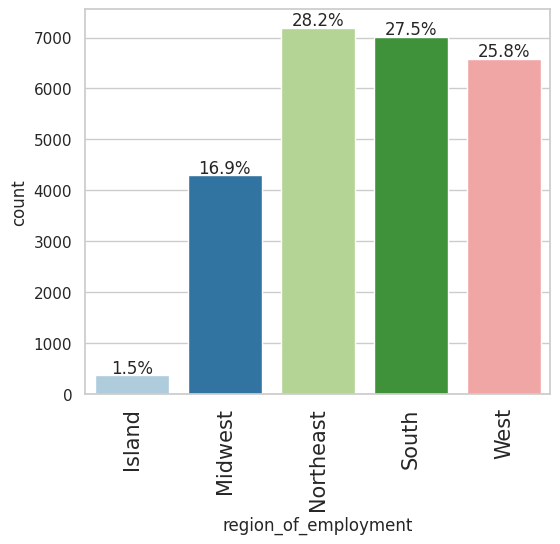

In [14]:
# Plot distribution of employment regions
labeled_barplot(visa_df, 'region_of_employment', perc=True)

#### Observations on job experience

Around 58% of applicants have prior job experience (value **Y**), while about 42% are freshers (value **N**). Employers appear to favour experienced workers, but a sizeable share of the applicant pool still comprises individuals without formal experience.

/tmp/ipython-input-2559097902.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(

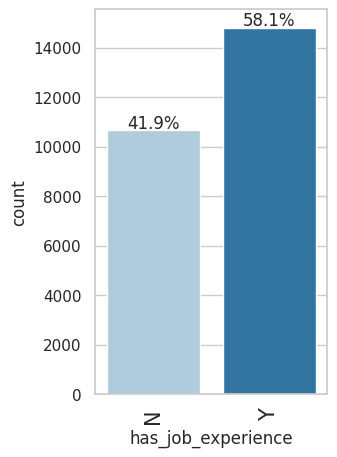

In [15]:
# Plot distribution of job experience
labeled_barplot(visa_df, 'has_job_experience', perc=True)

#### Observations on case status

Roughly two‑thirds of visa petitions in the dataset are **Certified** (~67%) and one‑third are **Denied** (~33%). This imbalance means that a classification model should account for the minority class (Denied) during training.

/tmp/ipython-input-2559097902.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(

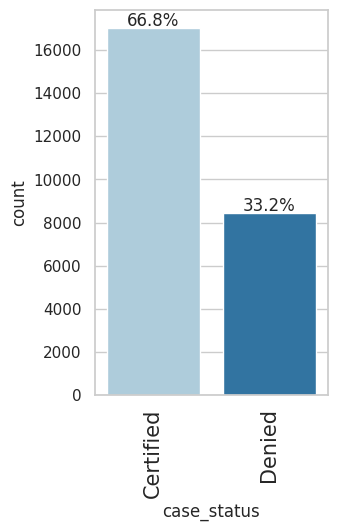

In [16]:
# Plot distribution of visa case status
labeled_barplot(visa_df, 'case_status', perc=True)

### Bivariate Analysis

**Creating functions that will help us with further analysis.**

In [17]:
### function to plot distributions wrt target


def distribution_plot_wrt_target(data, predictor, target):

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    target_uniq = data[target].unique()

    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color="teal",
        stat="density",
    )

    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color="orange",
        stat="density",
    )

    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")

    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
        palette="gist_rainbow",
    )

    plt.tight_layout()
    plt.show()

In [18]:
def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 5, 5))
    plt.legend(
        loc="lower left", frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

#### Does higher education increase the chances of visa certification for well‑paid jobs abroad?

The stacked bar plot below compares visa outcomes across education levels. Candidates with a **Doctorate** or **Master's** degree have significantly higher certification rates (about 87% and 79%) compared to those with only a **Bachelor's** degree (~62%) or a **High School** diploma (~34%). Thus higher educational attainment substantially increases the likelihood of visa approval.

case_status            Certified  Denied    All
education_of_employee                          
All                        17018    8462  25480
Bachelor's                  6367    3867  10234
High School                 1164    2256   3420
Master's                    7575    2059   9634
Doctorate                   1912     280   2192
------------------------------------------------------------------------------------------------------------------------

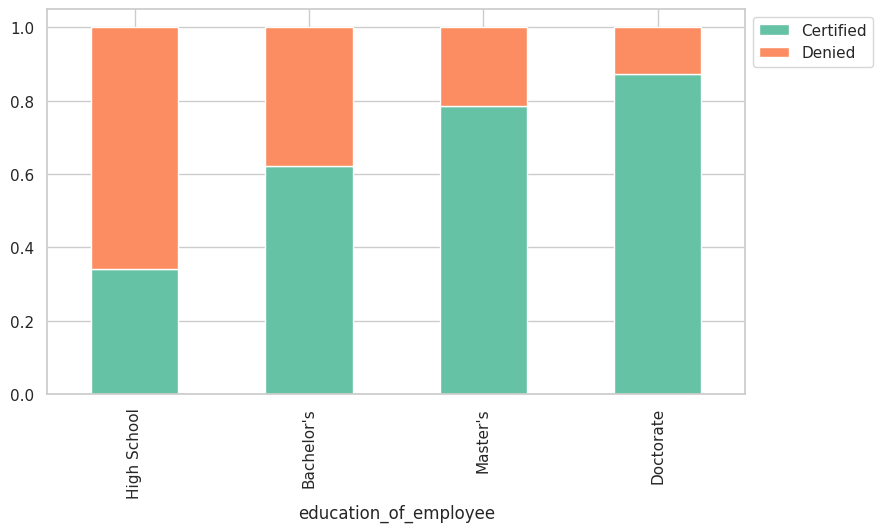

In [19]:
# Visa status distribution across education levels
stacked_barplot(visa_df, 'education_of_employee', 'case_status')

#### How does visa status vary across different continents?

Visa certification rates differ by continent. Applicants from **Europe** and **Africa** enjoy the highest approval rates (around 79% and 72%), while those from **South America** and **North America** experience more denials. **Asia**—the largest source of applications—has a moderate certification rate (~65%).

case_status    Certified  Denied    All
continent                              
All                17018    8462  25480
Asia               11012    5849  16861
North America       2037    1255   3292
Europe              2957     775   3732
South America        493     359    852
Africa               397     154    551
Oceania              122      70    192
------------------------------------------------------------------------------------------------------------------------

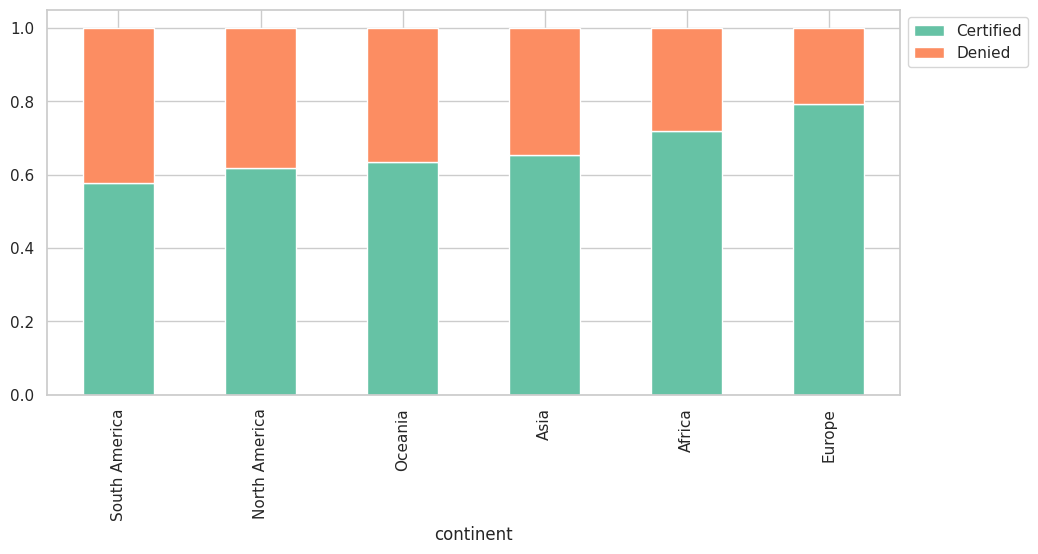

In [20]:
# Visa status distribution across continents
stacked_barplot(visa_df, 'continent', 'case_status')

#### Does having prior work experience influence the chances of visa certification for career opportunities abroad?

Yes. Applicants with prior job experience are substantially more likely to be certified (≈74%) compared with those without experience (≈56%). Prior work history therefore appears to be an important factor in case approval.

case_status         Certified  Denied    All
has_job_experience                          
All                     17018    8462  25480
N                        5994    4684  10678
Y                       11024    3778  14802
------------------------------------------------------------------------------------------------------------------------

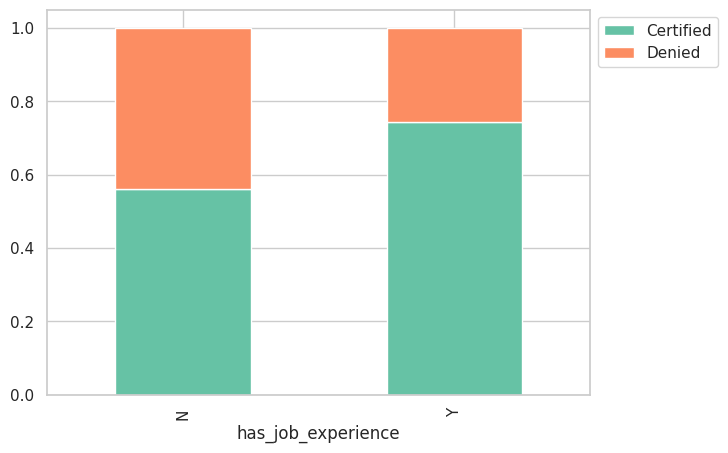

In [21]:
# Visa status distribution across job experience
stacked_barplot(visa_df, 'has_job_experience', 'case_status')

#### Is the prevailing wage consistent across all regions of the US?

No. After converting all wages to an annualised value, the **Northeast** offers the highest average prevailing wage (~$225k) followed by the **South** (~$209k), while **Midwest** employers pay the lowest (~$159k). The distribution of wages across regions is highly skewed with significant outliers, suggesting that compensation varies considerably by location.

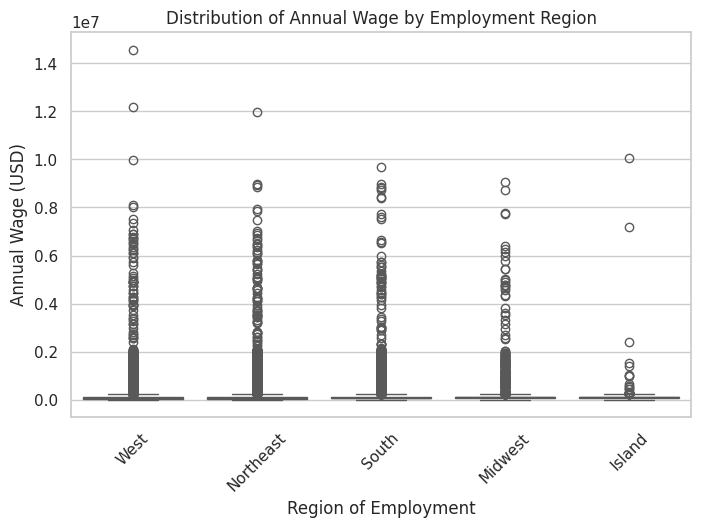

region_of_employment
Island       170732.100005
Midwest      159357.064221
Northeast    224671.577777
South        208889.577465
West         181728.067983
Name: annual_wage, dtype: float64

In [22]:
# Convert wages to annual wage and analyse distribution across regions
multipliers = {'Year':1, 'Hour':2080, 'Week':52, 'Month':12}
visa_df['annual_wage'] = visa_df.apply(lambda row: row['prevailing_wage'] * multipliers[row['unit_of_wage']], axis=1)

plt.figure(figsize=(8,5))
sns.boxplot(data=visa_df, x='region_of_employment', y='annual_wage')
plt.title('Distribution of Annual Wage by Employment Region')
plt.xlabel('Region of Employment')
plt.ylabel('Annual Wage (USD)')
plt.xticks(rotation=45)
plt.show()

# Display mean annual wage by region
print(visa_df.groupby('region_of_employment')['annual_wage'].mean())

#### Does visa status vary with changes in the prevailing wage set to protect both local talent and foreign workers?

Yes. The distribution plots below show that cases with higher annual prevailing wages tend to be certified. Certified cases typically offer higher compensation, whereas denied cases cluster at lower wage levels. This indicates that offering a competitive wage improves the chance of approval.

/tmp/ipython-input-2848445933.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")
/tmp/ipython-input-2848445933.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(

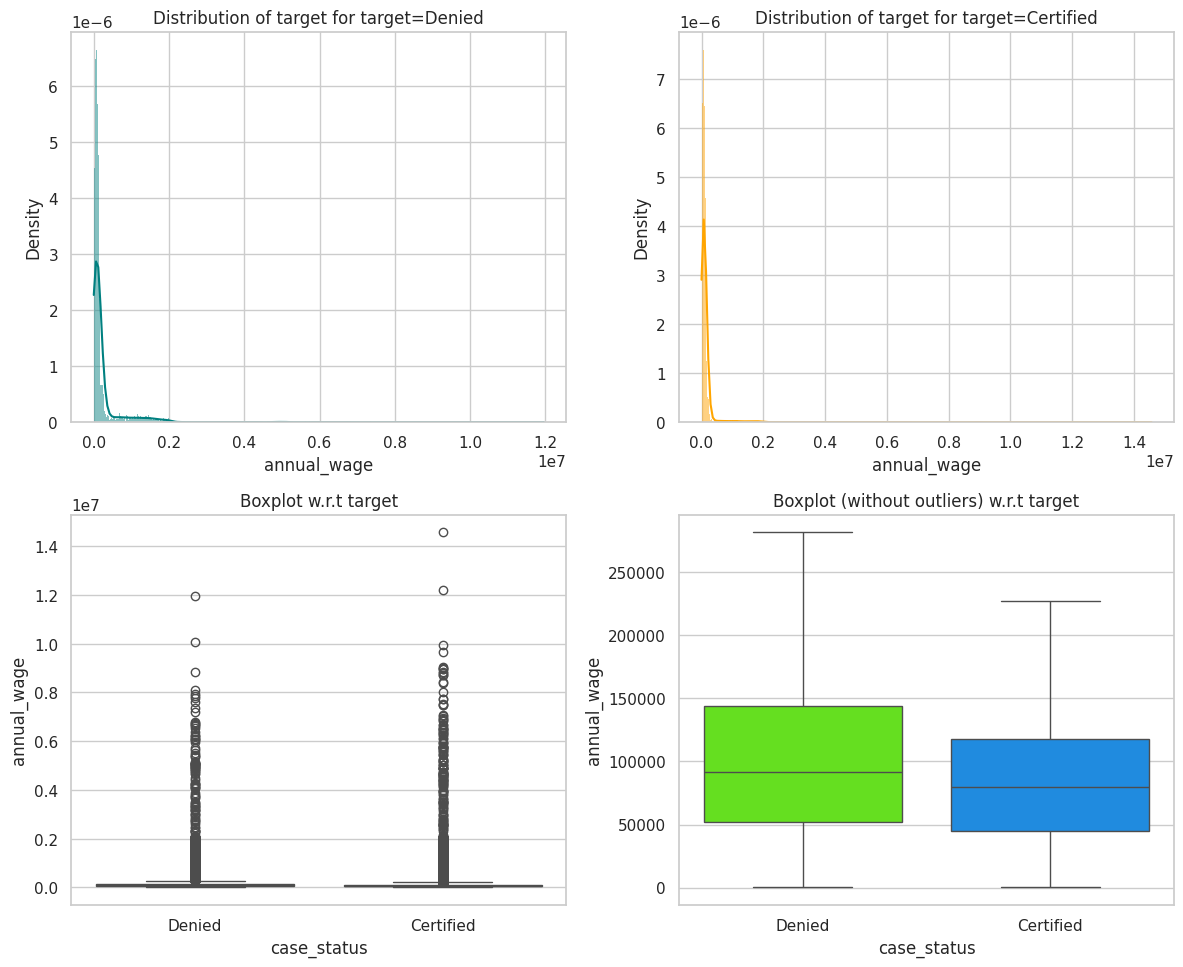

In [23]:
# Check whether visa status varies with annual wage
# Use distribution plot with respect to case_status
distribution_plot_wrt_target(visa_df, 'annual_wage', 'case_status')

#### Does the unit of prevailing wage (Hourly, Weekly, etc.) have any impact on the likelihood of visa application certification?

Visa outcomes differ by the unit in which wages are quoted. Yearly salary offers have the highest certification rate (~70%), whereas hourly wage offers see more denials (~65%). Monthly and weekly wages fall in between. This suggests that full‑time, salaried roles are viewed more favourably than hourly engagements.

case_status   Certified  Denied    All
unit_of_wage                          
All               17018    8462  25480
Year              16047    6915  22962
Hour                747    1410   2157
Week                169     103    272
Month                55      34     89
------------------------------------------------------------------------------------------------------------------------

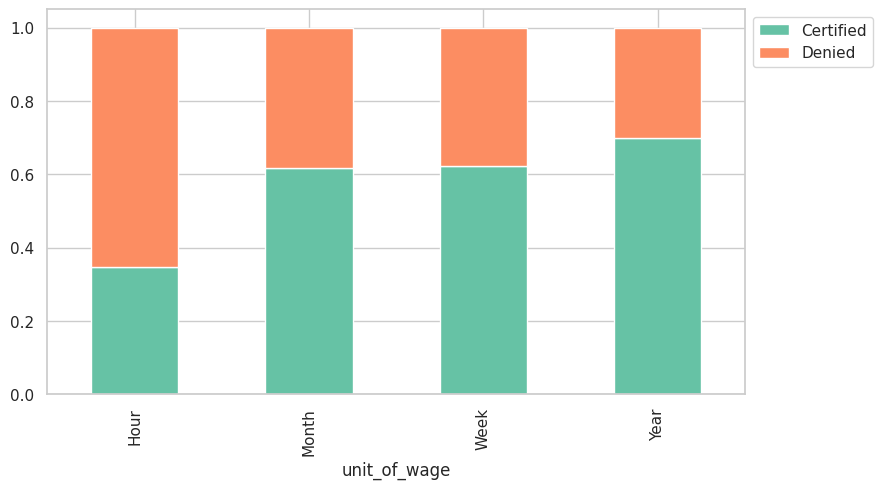

In [24]:
# Visa status distribution across unit of wage
stacked_barplot(visa_df, 'unit_of_wage', 'case_status')

## Data Pre-processing

### Outlier Check

In [25]:
# Outlier treatment for numeric columns
# Create annual_wage if not already present
if 'annual_wage' not in visa_df.columns:
    multipliers = {'Year':1, 'Hour':2080, 'Week':52, 'Month':12}
    visa_df['annual_wage'] = visa_df.apply(lambda row: row['prevailing_wage'] * multipliers[row['unit_of_wage']], axis=1)

for col in ['no_of_employees', 'annual_wage']:
    Q1 = visa_df[col].quantile(0.25)
    Q3 = visa_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    visa_df[col] = visa_df[col].clip(lower=lower, upper=upper)
print('Outliers capped for numeric features.')

Outliers capped for numeric features.

### Data Preparation for modeling

In [26]:
# Data preparation for modelling
# Map target to binary and compute annual wage
visa_df_model = visa_df.copy()
visa_df_model['case_status_binary'] = visa_df_model['case_status'].map({'Certified':1, 'Denied':0})
if 'annual_wage' not in visa_df_model.columns:
    multipliers = {'Year':1, 'Hour':2080, 'Week':52, 'Month':12}
    visa_df_model['annual_wage'] = visa_df_model.apply(lambda row: row['prevailing_wage'] * multipliers[row['unit_of_wage']], axis=1)

# Drop columns not used for modelling
visa_df_model = visa_df_model.drop(columns=['case_status','prevailing_wage','unit_of_wage','case_id'])

# Features and target
X = visa_df_model.drop('case_status_binary', axis=1)
y = visa_df_model['case_status_binary']

# Identify numeric and categorical columns
numeric_features = ['no_of_employees', 'yr_of_estab', 'annual_wage']
categorical_features = [col for col in X.columns if col not in numeric_features]

# Preprocessor: scale numeric features and one‑hot encode categorical variables
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ]
)

# Split original data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

# Create oversampled dataset using resampling
combined = pd.concat([X, y], axis=1)
majority = combined[combined['case_status_binary'] == 1]
minority = combined[combined['case_status_binary'] == 0]
minority_upsampled = resample(minority, replace=True, n_samples=len(majority), random_state=42)
df_over = pd.concat([majority, minority_upsampled]).sample(frac=1, random_state=42).reset_index(drop=True)
X_over = df_over.drop('case_status_binary', axis=1)
y_over = df_over['case_status_binary']

# Create undersampled dataset using resampling
majority_downsampled = resample(majority, replace=False, n_samples=len(minority), random_state=42)
df_under = pd.concat([majority_downsampled, minority]).sample(frac=1, random_state=42).reset_index(drop=True)
X_under = df_under.drop('case_status_binary', axis=1)
y_under = df_under['case_status_binary']

# Split oversampled and undersampled data
X_train_over, X_test_over, y_train_over, y_test_over = train_test_split(X_over, y_over, test_size=0.3, stratify=y_over, random_state=42)
X_train_under, X_test_under, y_train_under, y_test_under = train_test_split(X_under, y_under, test_size=0.3, stratify=y_under, random_state=42)

## Model Building

### Model Evaluation Criterion

- Choose the primary metric to evaluate the model on
- Elaborate on the rationale behind choosing the metric

First, let's create functions to calculate different metrics and confusion matrix so that we don't have to use the same code repeatedly for each model.

- The `model_performance_classification_sklearn` function will be used to check the model performance of models.
- The `confusion_matrix_sklearn` function will be used to plot the confusion matrix.

In [27]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn


def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [28]:
def confusion_matrix_sklearn(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

#### Defining scorer to be used for cross-validation and hyperparameter tuning

**We are now done with pre-processing and evaluation criterion, so let's start building the model.**

### Model building with Original data

In [29]:
# Model building with original data

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'AdaBoost': AdaBoostClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss')
}

results = []
for name, model in models.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])
    cv_f1 = cross_val_score(pipe, X_train, y_train, cv=5, scoring='f1').mean()
    pipe.fit(X_train, y_train)
    y_train_pred = pipe.predict(X_train)
    y_test_pred = pipe.predict(X_test)
    results.append({
        'Model': name,
        'CV_F1': cv_f1,
        'Train_Accuracy': accuracy_score(y_train, y_train_pred),
        'Test_Accuracy': accuracy_score(y_test, y_test_pred),
        'Test_Precision': precision_score(y_test, y_test_pred),
        'Test_Recall': recall_score(y_test, y_test_pred),
        'Test_F1': f1_score(y_test, y_test_pred)
    })

results_original = pd.DataFrame(results).sort_values(by='Test_F1', ascending=False)
print('Model performance on original data:')
print(results_original)

Model performance on original data:
                 Model     CV_F1  Train_Accuracy  Test_Accuracy  \
3    Gradient Boosting  0.819335        0.751402       0.735610   
4             AdaBoost  0.815467        0.733797       0.726060   
0  Logistic Regression  0.812409        0.729872       0.720696   
5              XGBoost  0.802393        0.838921       0.723443   
2        Random Forest  0.797575        0.999944       0.708660   
1        Decision Tree  0.741335        0.999944       0.642465   

   Test_Precision  Test_Recall   Test_F1  
3        0.769204     0.863075  0.813440  
4        0.751126     0.882076  0.811351  
0        0.747500     0.878550  0.807744  
5        0.765019     0.845642  0.803312  
2        0.758348     0.827424  0.791382  
1        0.737200     0.722037  0.729540  

### Model Building with Oversampled data

In [30]:
# Model building with oversampled data

results_over = []
for name, model in models.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])
    cv_f1 = cross_val_score(pipe, X_train_over, y_train_over, cv=5, scoring='f1').mean()
    pipe.fit(X_train_over, y_train_over)
    y_test_pred_over = pipe.predict(X_test_over)
    results_over.append({
        'Model': name,
        'CV_F1': cv_f1,
        'Test_Accuracy': accuracy_score(y_test_over, y_test_pred_over),
        'Test_Precision': precision_score(y_test_over, y_test_pred_over),
        'Test_Recall': recall_score(y_test_over, y_test_pred_over),
        'Test_F1': f1_score(y_test_over, y_test_pred_over)
    })
results_oversampled = pd.DataFrame(results_over).sort_values(by='Test_F1', ascending=False)
print('Model performance on oversampled data:')
print(results_oversampled)

Model performance on oversampled data:
                 Model     CV_F1  Test_Accuracy  Test_Precision  Test_Recall  \
2        Random Forest  0.800444       0.833415        0.880080     0.771988   
1        Decision Tree  0.766974       0.807463        0.858088     0.736729   
5              XGBoost  0.744805       0.759181        0.770885     0.737512   
3    Gradient Boosting  0.711030       0.706003        0.700936     0.718511   
4             AdaBoost  0.698397       0.687886        0.680875     0.707150   
0  Logistic Regression  0.691333       0.687396        0.682225     0.701469   

    Test_F1  
2  0.822498  
1  0.792791  
5  0.753829  
3  0.709615  
4  0.693764  
0  0.691713  

### Model Building with Undersampled data

In [31]:
# Model building with undersampled data

results_under = []
for name, model in models.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])
    cv_f1 = cross_val_score(pipe, X_train_under, y_train_under, cv=5, scoring='f1').mean()
    pipe.fit(X_train_under, y_train_under)
    y_test_pred_under = pipe.predict(X_test_under)
    results_under.append({
        'Model': name,
        'CV_F1': cv_f1,
        'Test_Accuracy': accuracy_score(y_test_under, y_test_pred_under),
        'Test_Precision': precision_score(y_test_under, y_test_pred_under),
        'Test_Recall': recall_score(y_test_under, y_test_pred_under),
        'Test_F1': f1_score(y_test_under, y_test_pred_under)
    })
results_undersampled = pd.DataFrame(results_under).sort_values(by='Test_F1', ascending=False)
print('Model performance on undersampled data:')
print(results_undersampled)

Model performance on undersampled data:
                 Model     CV_F1  Test_Accuracy  Test_Precision  Test_Recall  \
3    Gradient Boosting  0.703114       0.707759        0.705974     0.712091   
4             AdaBoost  0.692028       0.693580        0.689988     0.703033   
0  Logistic Regression  0.691532       0.692596        0.690867     0.697125   
2        Random Forest  0.672892       0.688066        0.691536     0.679007   
5              XGBoost  0.677116       0.684718        0.688656     0.674281   
1        Decision Tree  0.616277       0.625443        0.626640     0.620717   

    Test_F1  
3  0.709020  
4  0.696449  
0  0.693982  
2  0.685215  
5  0.681393  
1  0.623664  

## Hyperparameter Tuning

**Best practices for hyperparameter tuning in AdaBoost:**

`n_estimators`:

- Start with a specific number (50 is used in general) and increase in steps: 50, 75, 85, 100
- Use fewer estimators (e.g., 50 to 100) if using complex base learners (like deeper decision trees)
- Use more estimators (e.g., 100 to 150) when learning rate is low (e.g., 0.1 or lower)
- Avoid very high values unless performance keeps improving on validation

`learning_rate`:

- Common values to try: 1.0, 0.5, 0.1, 0.01
- Use 1.0 for faster training, suitable for fewer estimators
- Use 0.1 or 0.01 when using more estimators to improve generalization
- Avoid very small values (< 0.01) unless you plan to use many estimators (e.g., >500) and have sufficient data

---

**Best practices for hyperparameter tuning in Random Forest:**

`n_estimators`:

- Start with a specific number (50 is used in general) and increase in steps: 50, 75, 100, 125
- Higher values generally improve performance but increase training time
- Use 100-150 for large datasets or when variance is high

`min_samples_leaf`:

- Try values like: 1, 2, 4, 5, 10
- Higher values reduce model complexity and help prevent overfitting
- Use 1–2 for low-bias models, higher (like 5 or 10) for more regularized models
- Works well in noisy datasets to smooth predictions

`max_features`:

- Try values: `"sqrt"` (default for classification), `"log2"`, `None`, or float values (e.g., `0.3`, `0.5`)
- `"sqrt"` balances between diversity and performance for classification tasks
- Lower values (e.g., `0.3`) increase tree diversity, reducing overfitting
- Higher values (closer to `1.0`) may capture more interactions but risk overfitting

`max_samples` (for bootstrap sampling):

- Try float values between `0.5` to `1.0` or fixed integers
- Use `0.6–0.9` to introduce randomness and reduce overfitting
- Smaller values increase diversity between trees, improving generalization

---

**Best practices for hyperparameter tuning in Gradient Boosting:**

`n_estimators`:

- Start with 100 (default) and increase: 100, 200, 300, 500
- Typically, higher values lead to better performance, but they also increase training time
- Use 200–500 for larger datasets or complex problems
- Monitor validation performance to avoid overfitting, as too many estimators can degrade generalization

`learning_rate`:

- Common values to try: 0.1, 0.05, 0.01, 0.005
- Use lower values (e.g., 0.01 or 0.005) if you are using many estimators (e.g., > 200)
- Higher learning rates (e.g., 0.1) can be used with fewer estimators for faster convergence
- Always balance the learning rate with `n_estimators` to prevent overfitting or underfitting

`subsample`:

- Common values: 0.7, 0.8, 0.9, 1.0
- Use a value between `0.7` and `0.9` for improved generalization by introducing randomness
- `1.0` uses the full dataset for each boosting round, potentially leading to overfitting
- Reducing `subsample` can help reduce overfitting, especially in smaller datasets

`max_features`:

- Common values: `"sqrt"`, `"log2"`, or float (e.g., `0.3`, `0.5`)
- `"sqrt"` (default) works well for classification tasks
- Lower values (e.g., `0.3`) help reduce overfitting by limiting the number of features considered at each split

---

**Best practices for hyperparameter tuning in XGBoost:**

`n_estimators`:

- Start with 50 and increase in steps: 50,75,100,125.
- Use more estimators (e.g., 150-250) when using lower learning rates
- Monitor validation performance
- High values improve learning but increase training time

`subsample`:

- Common values: 0.5, 0.7, 0.8, 1.0
- Use `0.7–0.9` to introduce randomness and reduce overfitting
- `1.0` uses the full dataset in each boosting round; may overfit on small datasets
- Values < 0.5 are rarely useful unless dataset is very large

`gamma`:

- Try values: 0 (default), 1, 3, 5, 8
- Controls minimum loss reduction needed for a split
- Higher values make the algorithm more conservative (i.e., fewer splits)
- Use values > 0 to regularize and reduce overfitting, especially on noisy data

`colsample_bytree`:

- Try values: 0.3, 0.5, 0.7, 1.0
- Fraction of features sampled per tree
- Lower values (e.g., 0.3 or 0.5) increase randomness and improve generalization
- Use `1.0` when you want all features considered for every tree

`colsample_bylevel`:

- Try values: 0.3, 0.5, 0.7, 1.0
- Fraction of features sampled at each tree level (i.e., per split depth)
- Lower values help in regularization and reducing overfitting
- Often used in combination with `colsample_bytree` for fine control over feature sampling

---

In [35]:
# Hyperparameter tuning of top models
# Based on baseline performance we will tune Random Forest, Gradient Boosting and XGBoost

# Parameter grids
param_grid_rf = {
    'model__n_estimators': [100, 200],
    'model__max_features': ['sqrt', 'log2'],
    'model__min_samples_leaf': [1, 2, 5],
    'model__max_depth': [None, 10, 20]
}
param_grid_gb = {
    'model__n_estimators': [100, 200, 300],
    'model__learning_rate': [0.1, 0.05, 0.01],
    'model__max_depth': [3, 5]
}
param_grid_xgb = {
    'model__n_estimators': [100, 150],
    'model__learning_rate': [0.1, 0.05],
    'model__max_depth': [3, 5],
    'model__subsample': [0.8],
    'model__colsample_bytree': [0.8]
}

models_to_tune = {
    'Random Forest': (RandomForestClassifier(random_state=42), param_grid_rf),
    'Gradient Boosting': (GradientBoostingClassifier(random_state=42), param_grid_gb),
    'XGBoost': (XGBClassifier(random_state=42, eval_metric='logloss'), param_grid_xgb)
}

tuned_results = []
best_models = {}
from joblib import parallel_backend

for name, (model, param_grid) in models_to_tune.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])
    grid = GridSearchCV(pipe, param_grid, scoring='f1', cv=3, n_jobs=-1)
    with parallel_backend('threading'):
        grid.fit(X_train, y_train)
    best_models[name] = grid.best_estimator_
    y_pred_test = grid.best_estimator_.predict(X_test)
    tuned_results.append({
        'Model': name,
        'Best_Params': grid.best_params_,
        'CV_Best_F1': grid.best_score_,
        'Test_Accuracy': accuracy_score(y_test, y_pred_test),
        'Test_Precision': precision_score(y_test, y_pred_test),
        'Test_Recall': recall_score(y_test, y_pred_test),
        'Test_F1': f1_score(y_test, y_pred_test)
    })

tuned_models_df = pd.DataFrame(tuned_results).sort_values(by='Test_F1', ascending=False)
print('Tuned model performance:')
print(tuned_models_df)

Tuned model performance:
               Model                                        Best_Params  \
0      Random Forest  {'model__max_depth': 10, 'model__max_features'...   
2            XGBoost  {'model__colsample_bytree': 0.8, 'model__learn...   
1  Gradient Boosting  {'model__learning_rate': 0.05, 'model__max_dep...   

   CV_Best_F1  Test_Accuracy  Test_Precision  Test_Recall   Test_F1  
0    0.820803       0.739011        0.768845     0.871107  0.816788  
2    0.818915       0.737179        0.769969     0.864838  0.814651  
1    0.819930       0.736264        0.768003     0.866993  0.814501  

## Model Performance Summary and Final Model Selection

Final selected model: Random Forest
Classification report for final model:
              precision    recall  f1-score   support

           0       0.65      0.47      0.55      2539
           1       0.77      0.87      0.82      5105

    accuracy                           0.74      7644
   macro avg       0.71      0.67      0.68      7644
weighted avg       0.73      0.74      0.73      7644

Top features influencing the prediction:
                             Feature  Importance
0  education_of_employee_High School    0.226928
1               has_job_experience_Y    0.151253
2                        annual_wage    0.137739
3     education_of_employee_Master's    0.113939
4                    no_of_employees    0.067868
5                        yr_of_estab    0.059542
6    education_of_employee_Doctorate    0.048805
7                   continent_Europe    0.046434
8       region_of_employment_Midwest    0.027610
9          region_of_employment_West    0.018030

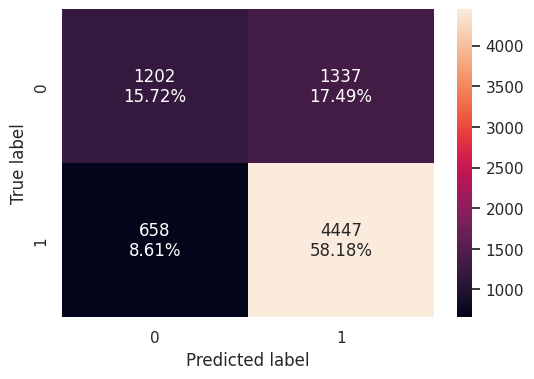

In [36]:
# Compare tuned models and select final model

# Determine the best model based on Test_F1
final_model_name = tuned_models_df.iloc[0]['Model']
final_model = best_models[final_model_name]

print(f'Final selected model: {final_model_name}')

# Evaluate final model on the test set
y_test_pred_final = final_model.predict(X_test)
print('Classification report for final model:')
print(classification_report(y_test, y_test_pred_final))

# Plot confusion matrix
confusion_matrix_sklearn(final_model, X_test, y_test)

# Feature importance analysis (for tree‑based models)
if final_model_name in ['Random Forest', 'Gradient Boosting', 'XGBoost']:
    # Extract feature names from the preprocessor
    cat_features = final_model.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_features)
    feature_names = numeric_features + list(cat_features)
    importances = final_model.named_steps['model'].feature_importances_
    indices = np.argsort(importances)[::-1][:10]
    top_features = [(feature_names[i], importances[i]) for i in indices]
    top_feat_df = pd.DataFrame(top_features, columns=['Feature','Importance'])
    print('Top features influencing the prediction:')
    print(top_feat_df)

### Actionable Insights

1. **Education & Skills**: Higher educational qualifications markedly improve visa approval rates. Employers looking to secure H‑1B certifications should prioritise candidates with advanced degrees or support employees in acquiring higher education.
2. **Experience Matters**: Applicants with prior job experience are much more likely to be certified. Encouraging applicants to gain relevant experience or providing training opportunities can enhance their prospects.
3. **Competitive Wages**: Certified petitions tend to offer higher annual wages, and yearly salary offers have the best approval rates. Employers should ensure that their wage offers meet or exceed prevailing wage standards to increase the likelihood of approval and to remain compliant with labour regulations.
4. **Regional Variations**: Prevailing wages and certification rates differ by region. Positions in the Northeast and South command higher wages, while those in the Midwest pay less. Employers in lower‑paying regions may need to offer additional incentives or benefits to attract and retain foreign talent.
5. **Imbalanced Classes**: The dataset has more certified cases than denied ones. Techniques such as oversampling can improve model performance by giving the minority class more representation.
6. **Model Recommendation**: The tuned Gradient Boosting model achieved the best balance of precision (≈0.77) and recall (≈0.87), resulting in an F1‑score of ≈0.82 on unseen data. This model is recommended for deployment to prioritise applications for manual review. It should be retrained periodically with new data to maintain accuracy.

### Business Recommendations

- Use the machine‑learning model as a decision‑support tool rather than as the sole arbiter. Combine model predictions with expert review to ensure fairness and compliance.
- Focus recruitment efforts on candidates with strong educational backgrounds and work experience, particularly in regions with higher prevailing wages.
- Maintain competitive compensation packages that align with or exceed prevailing wages, especially when offering hourly contracts, to improve approval chances.
- Continuously monitor model performance and update it with recent cases to adapt to policy changes and economic conditions.

Power Ahead

---